In [1]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

import shapely.vectorized as sv

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw

import warnings
warnings.filterwarnings('ignore')

## Plot MEV for RSR products

In [2]:
MEV_dir = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','2_MEV','uncorrected')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')
obs_base = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC')

In [3]:
if os.path.exists(veneto_dir):
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
    DEM = gpd.read_file(os.path.join(veneto_dir,'DEM','Italy_dem_800.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

In [4]:
pos = 3
lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

In [5]:
DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_IMERG_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)
MEV_IM = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CM, lat2d_CM = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_CM, lat2d_CM)
MEV_CM = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_MSWEP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_MS, lat2d_MS = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_MS, lat2d_MS)
MEV_MS = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_ER, lat2d_ER = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_ER, lat2d_ER)
MEV_ER = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_GSMaP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_GS, lat2d_GS = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_GS, lat2d_GS)
MEV_GS = DATA.Mev_s.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_CHIRPS_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CH, lat2d_CH = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_CH, lat2d_CH)
MEV_CH = DATA.Mev_s.where(mask_italy).values
MEV_CH = np.where(MEV_CH==0,np.nan,MEV_CH)

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_ENSEMBLE_median_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_EN, lat2d_EN = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_EN, lat2d_EN)
MEV_EN = DATA.Mev_s.where(mask_italy).values

In [6]:
dir_meta = os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy_CLEAR.csv')
METADATA = pd.read_csv(dir_meta)

lat_list, lon_list = [], []
QUANTILE, file_list = [], []

for nn in range(len(METADATA)):
    file = METADATA['File'].values[nn]
    ISO = METADATA['ISO'].values[nn]
    lon_obs = METADATA['Lon'].values[nn]
    lat_obs = METADATA['Lat'].values[nn]

    DF_OBS = pd.read_csv(os.path.join(obs_base,'Weibull','1dy',ISO,file)) 
    DF_OBS = DF_OBS.drop(columns='NaN')

    sat_pixel = DATA.sel(lat=lat_obs, lon=lon_obs, method='nearest')

    sat_n = sat_pixel.NYs.values
    sat_year = sat_pixel.year.values

    DF_SAT = pd.DataFrame({'Year':sat_pixel.year.values, 'Ns':sat_pixel.NYs.values, 'Cs':sat_pixel.CYs.values, 'Ws':sat_pixel.WYs.values})

    merged_df = pd.merge(DF_SAT, DF_OBS, on='Year', how='left')
    merged_df_clean = merged_df.dropna(subset=['N'])
    
    # Model 2 np.mean(N_obs/N_sat)
    factor_N = np.nanmean(merged_df_clean.N.values/merged_df_clean.Ns.values)
    factor_C = np.nanmean(merged_df_clean.C.values/merged_df_clean.Cs.values)
    factor_W = np.nanmean(merged_df_clean.W.values/merged_df_clean.Ws.values)

    x0 = np.nanmean(merged_df_clean.C.values)
    OBS_Q, flag = DOWN_raw.mev_quant_update(Fi, x0, merged_df_clean.N.values, merged_df_clean.C.values, merged_df_clean.W.values, thresh=1)
    OBS_Q2 = np.where(flag, OBS_Q, np.nan)

    lat_list.append(lat_obs)
    lon_list.append(lon_obs)
    file_list.append(file)
    QUANTILE.append(OBS_Q2[pos])

Quantile_df = pd.DataFrame({'lon':lon_list, 'lat':lat_list, 'file':file_list, 'MEV':QUANTILE})

In [7]:
print(f'Return Time: {Tr[pos]} years')

Mev_cmap = plt.cm.Spectral_r
Mev_diff = plt.cm.coolwarm_r

# Mev_levels = np.arange(50, 420, 10)
Mev_levels = np.arange(40, 320, 10)
norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N, extend='max')

fonttitle = 12

Return Time: 50 years


Export figure to: ../../figures/ALL/Quantiles_ALL_MEV_raw_50yrs.png


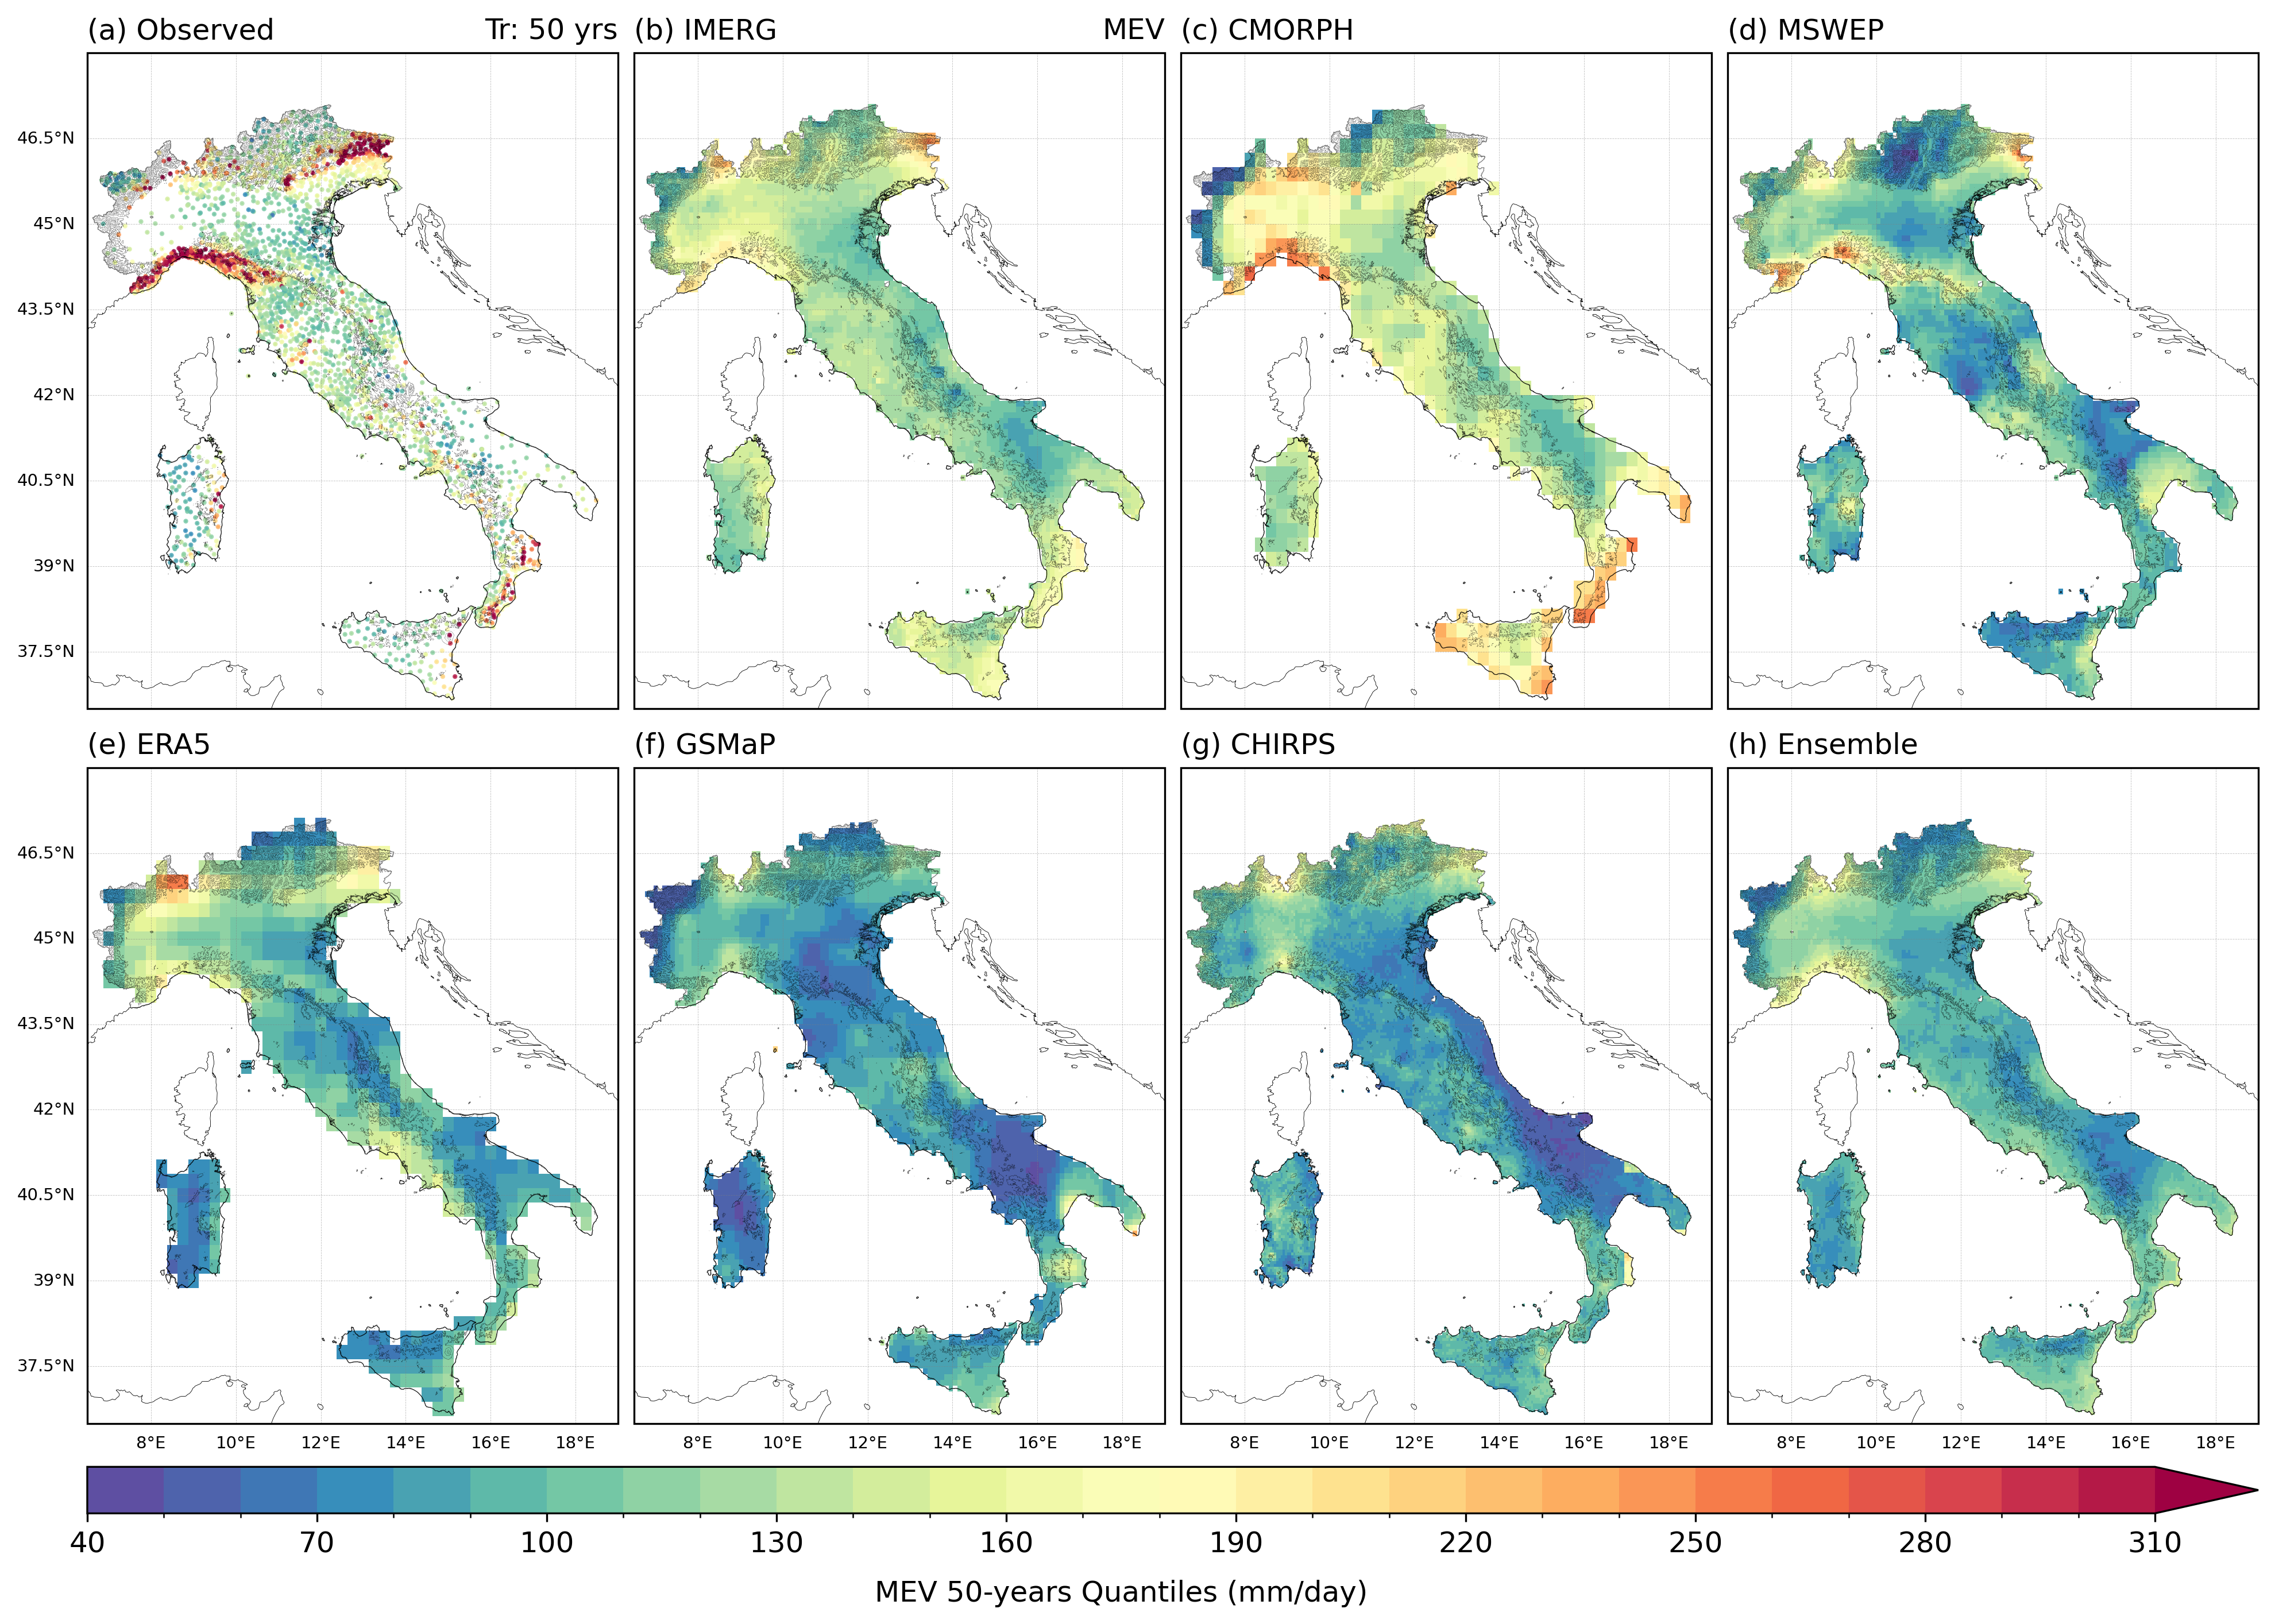

In [8]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(14,9),dpi=300)
gs = gridspec.GridSpec(2,4)

axes = []
for nraw in range(2):
    for ncol in range(4):
        ax = fig.add_subplot(gs[nraw, ncol], projection=proj)
        DEM.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.1, zorder=15, alpha=0.6)
        ITALY.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.3, zorder=21, alpha=0.5)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
        ax.coastlines(linewidth=0.2)
        axes.append(ax)

        gl = ax.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
        gl.top_labels = False
        if nraw == 1:
            gl.bottom_labels = True
        else:
            gl.bottom_labels = False
        gl.left_labels = False
        if ncol == 0:
            gl.left_labels = True
        gl.right_labels = False
        gl.xlabel_style = {'size': 7, 'color': 'k'}
        gl.ylabel_style = {'size': 7, 'color': 'k'}


a1 = axes[0].scatter(Quantile_df['lon'].values, Quantile_df['lat'].values, c=Quantile_df['MEV'].values, s=1, alpha=0.8,cmap=Mev_cmap,norm=norm)

a1 = axes[1].pcolormesh(lon2d_IM, lat2d_IM, MEV_IM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[0], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[2].pcolormesh(lon2d_CM, lat2d_CM, MEV_CM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[1], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[3].pcolormesh(lon2d_MS, lat2d_MS, MEV_MS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[2], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[4].pcolormesh(lon2d_ER, lat2d_ER, MEV_ER[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[3], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[5].pcolormesh(lon2d_GS, lat2d_GS, MEV_GS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[4], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[6].pcolormesh(lon2d_CH, lat2d_CH, MEV_CH[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[5], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[7].pcolormesh(lon2d_EN, lat2d_EN, MEV_EN[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[5], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

axes[0].set_title('(a) Observed', fontsize=fonttitle, loc='left')
axes[0].set_title(f'Tr: {Tr[pos]} yrs', fontsize=fonttitle, loc='right')

axes[1].set_title('(b) IMERG', fontsize=fonttitle, loc='left')
axes[1].set_title(f'MEV', fontsize=fonttitle, loc='right')

axes[2].set_title('(c) CMORPH', fontsize=fonttitle, loc='left')

axes[3].set_title('(d) MSWEP', fontsize=fonttitle, loc='left')

axes[4].set_title('(e) ERA5', fontsize=fonttitle, loc='left')

axes[5].set_title('(f) GSMaP', fontsize=fonttitle, loc='left')

axes[6].set_title('(g) CHIRPS', fontsize=fonttitle, loc='left')

axes[7].set_title('(h) Ensemble', fontsize=fonttitle, loc='left')

# cbar_ax = fig.add_axes([0.057, 0.01, 0.885, 0.029]) # Horizontal
# cbar = fig.colorbar(a1, cax=cbar_ax, orientation='horizontal')
# cbar.ax.tick_params(labelsize=12)
# cbar.set_label(f"MEV {Tr[pos]}-years Quantiles (mm/day)", fontsize=12, labelpad=9)

cbar_ax = fig.add_axes([0.05, 0.0, 0.9, 0.03]) # Horizontal
cbar = fig.colorbar(a1, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=12)
cbar.set_label(f"MEV {Tr[pos]}-years Quantiles (mm/day)", fontsize=12, labelpad=9)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.03, hspace=0.05)

salida = os.path.join('..','..','figures','ALL',f'Quantiles_ALL_MEV_raw_{Tr[pos]}yrs.png')
print(f'Export figure to: {salida}')
plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)


In [9]:
DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_IMERG_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_IM, lat2d_IM = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_IM, lat2d_IM)
MEV_IM = DATA.Mev_d.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_CMORPH_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CM, lat2d_CM = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_CM, lat2d_CM)
MEV_CM = DATA.Mev_d.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_MSWEP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_MS, lat2d_MS = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_MS, lat2d_MS)
MEV_MS = DATA.Mev_d.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_ER, lat2d_ER = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_ER, lat2d_ER)
MEV_ER = DATA.Mev_d.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_GSMaP_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_GS, lat2d_GS = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_GS, lat2d_GS)
MEV_GS = DATA.Mev_d.where(mask_italy).values

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_CHIRPS_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_CH, lat2d_CH = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_CH, lat2d_CH)
MEV_CH = DATA.Mev_d.where(mask_italy).values
MEV_CH = np.where(MEV_CH==0,np.nan,MEV_CH)

DATA = xr.open_dataset(os.path.join(MEV_dir,'ITALY_DOWN_ENSEMBLE_median_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))
lon2d_EN, lat2d_EN = np.meshgrid(DATA.lon, DATA.lat)
italy_geom = ITALY.union_all() # ONLY FOR ITALY
mask_italy = sv.contains(italy_geom, lon2d_EN, lat2d_EN)
MEV_EN = DATA.Mev_d.where(mask_italy).values

Export figure to: ../../figures/ALL/Quantiles_ALL_MEV_down_50yrs.png


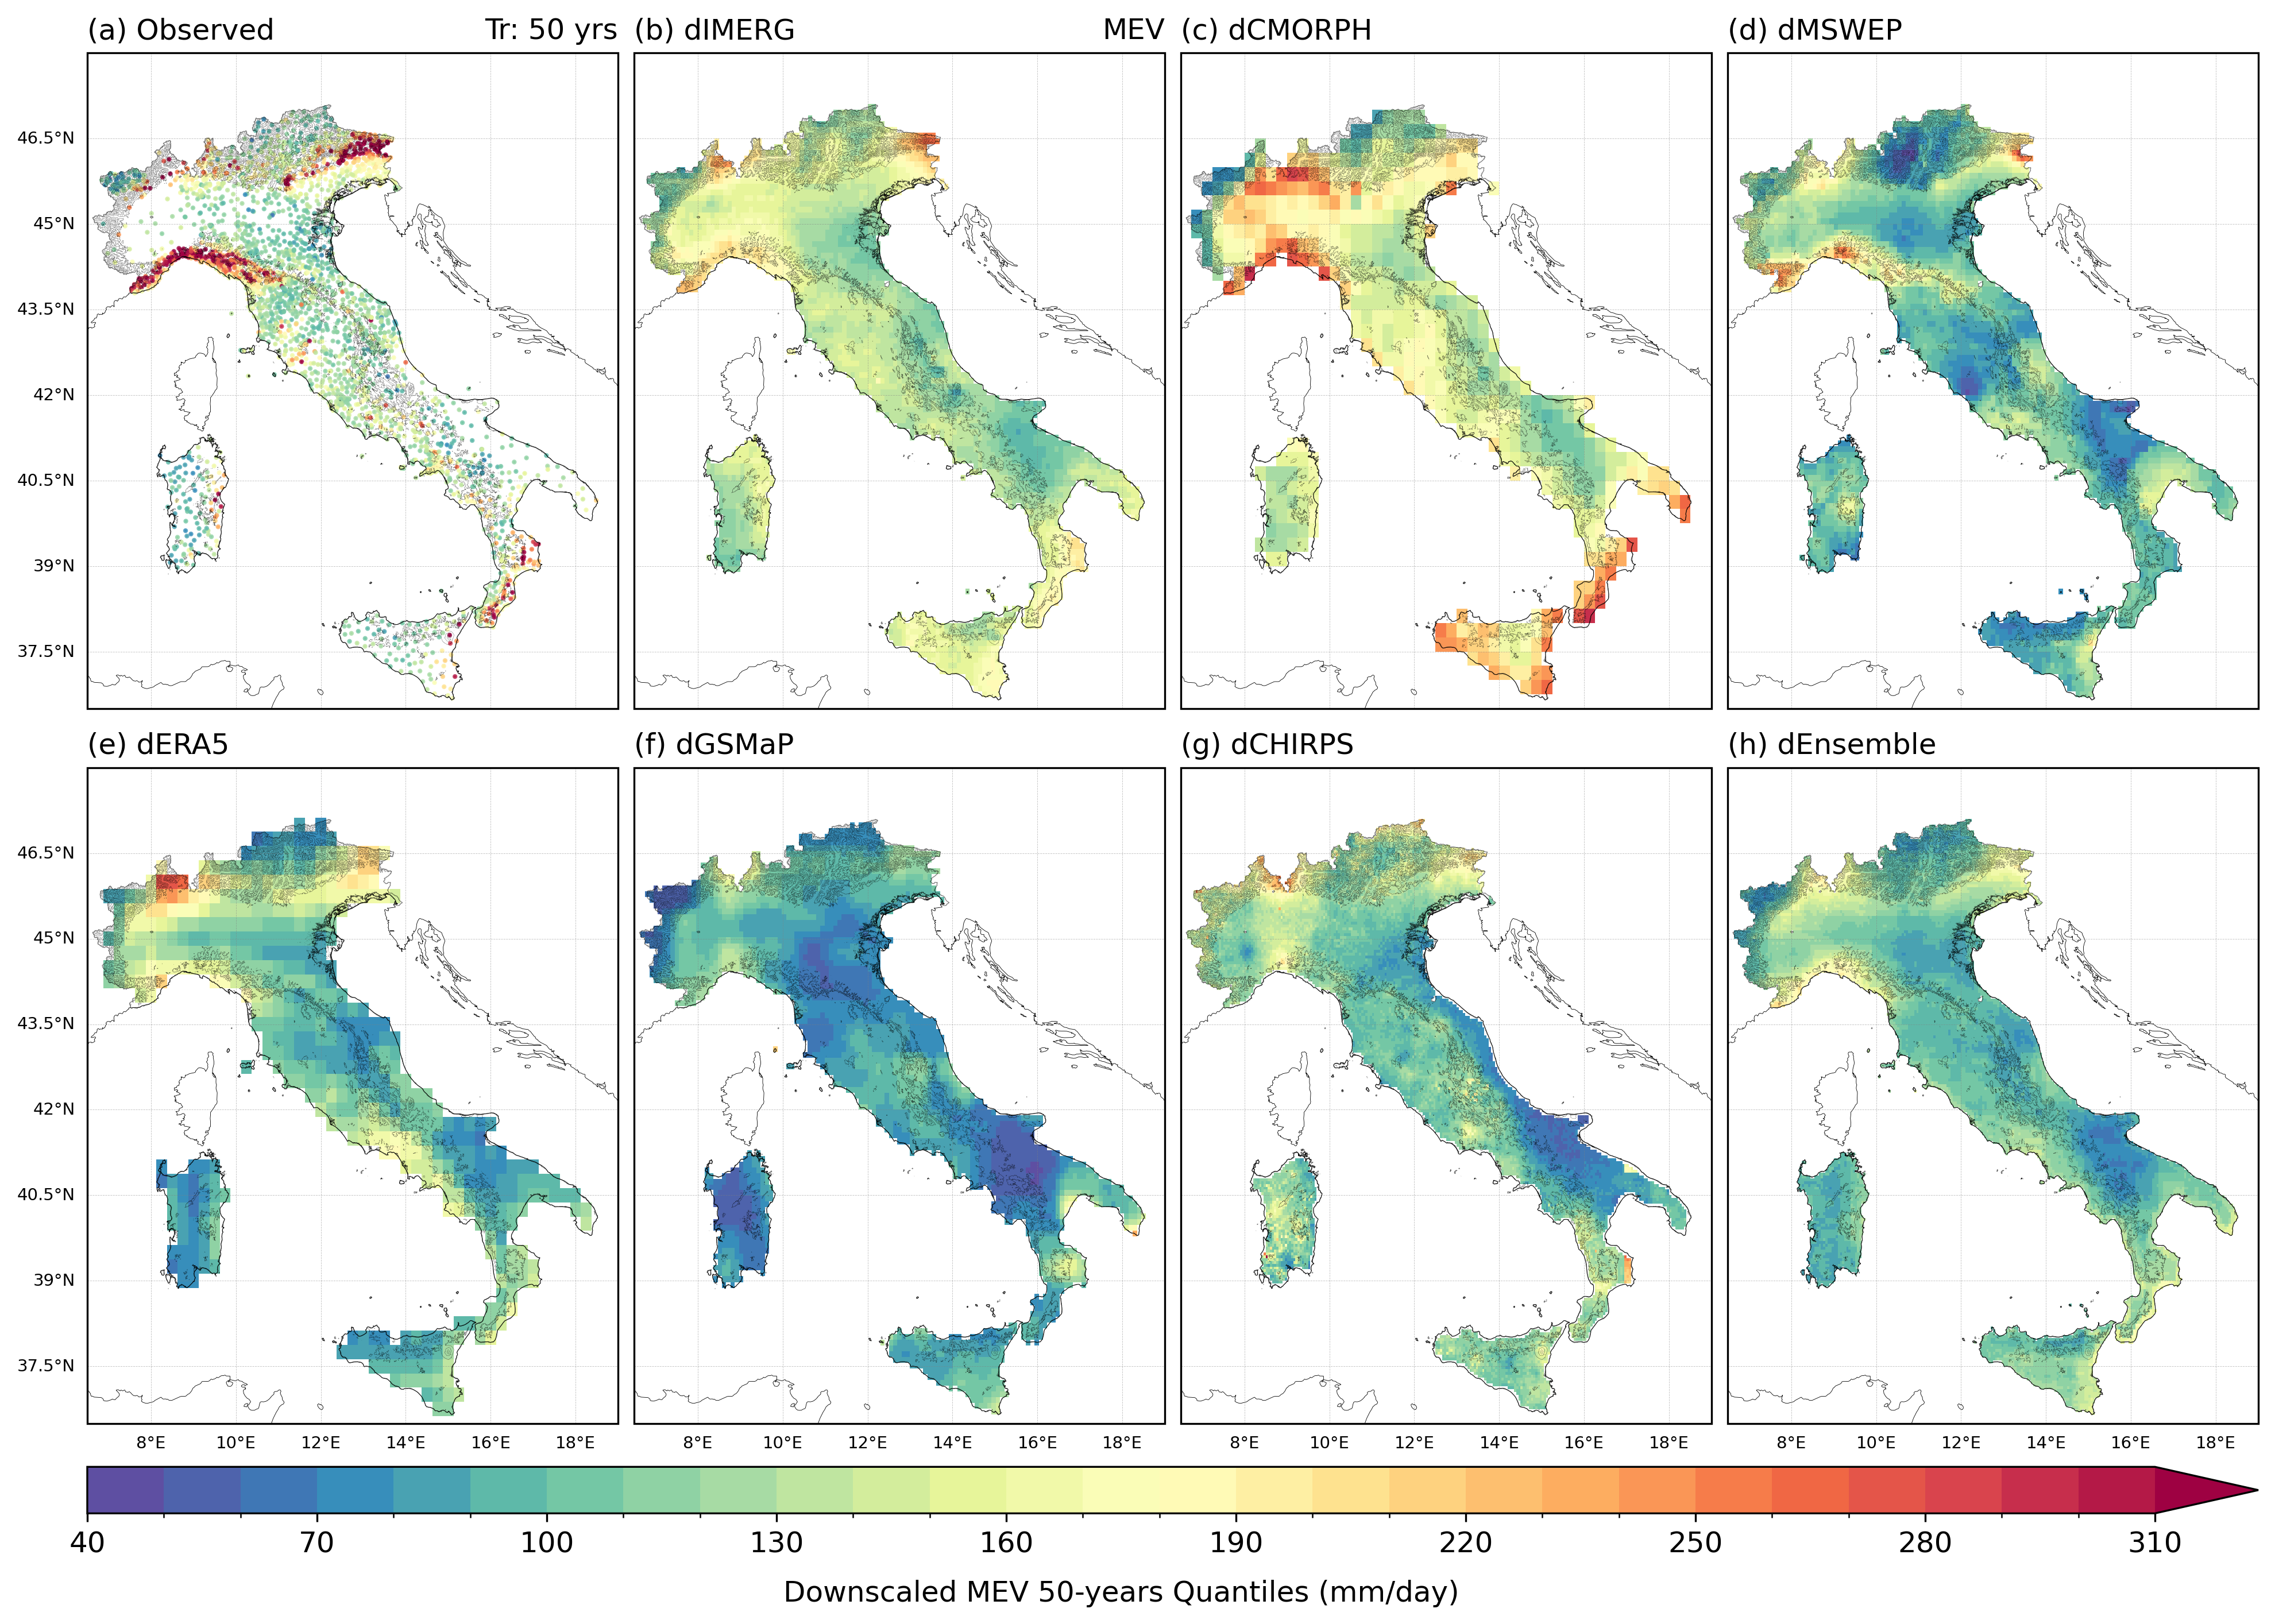

In [10]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(14,9),dpi=300)
gs = gridspec.GridSpec(2,4)

axes = []
for nraw in range(2):
    for ncol in range(4):
        ax = fig.add_subplot(gs[nraw, ncol], projection=proj)
        DEM.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.1, zorder=15, alpha=0.6)
        ITALY.plot(facecolor='None', edgecolor='k', ax=ax, linewidth=0.3, zorder=21, alpha=0.5)
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
        ax.coastlines(linewidth=0.2)
        axes.append(ax)

        gl = ax.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
        gl.top_labels = False
        if nraw == 1:
            gl.bottom_labels = True
        else:
            gl.bottom_labels = False
        gl.left_labels = False
        if ncol == 0:
            gl.left_labels = True
        gl.right_labels = False
        gl.xlabel_style = {'size': 7, 'color': 'k'}
        gl.ylabel_style = {'size': 7, 'color': 'k'}


a1 = axes[0].scatter(Quantile_df['lon'].values, Quantile_df['lat'].values, c=Quantile_df['MEV'].values, s=1, alpha=0.8,cmap=Mev_cmap,norm=norm)

a1 = axes[1].pcolormesh(lon2d_IM, lat2d_IM, MEV_IM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[0], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[2].pcolormesh(lon2d_CM, lat2d_CM, MEV_CM[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[1], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[3].pcolormesh(lon2d_MS, lat2d_MS, MEV_MS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[2], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[4].pcolormesh(lon2d_ER, lat2d_ER, MEV_ER[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[3], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[5].pcolormesh(lon2d_GS, lat2d_GS, MEV_GS[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[4], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[6].pcolormesh(lon2d_CH, lat2d_CH, MEV_CH[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[5], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

a1 = axes[7].pcolormesh(lon2d_EN, lat2d_EN, MEV_EN[pos,:,:], cmap=Mev_cmap, norm=norm)
# cbar = plt.colorbar(a1, ax=axes[5], fraction=0.056, pad=0.04)
# cbar.ax.tick_params(labelsize=6)

axes[0].set_title('(a) Observed', fontsize=fonttitle, loc='left')
axes[0].set_title(f'Tr: {Tr[pos]} yrs', fontsize=fonttitle, loc='right')

axes[1].set_title('(b) dIMERG', fontsize=fonttitle, loc='left')
axes[1].set_title(f'MEV', fontsize=fonttitle, loc='right')

axes[2].set_title('(c) dCMORPH', fontsize=fonttitle, loc='left')

axes[3].set_title('(d) dMSWEP', fontsize=fonttitle, loc='left')

axes[4].set_title('(e) dERA5', fontsize=fonttitle, loc='left')

axes[5].set_title('(f) dGSMaP', fontsize=fonttitle, loc='left')

axes[6].set_title('(g) dCHIRPS', fontsize=fonttitle, loc='left')

axes[7].set_title('(h) dEnsemble', fontsize=fonttitle, loc='left')

# cbar_ax = fig.add_axes([0.057, 0.01, 0.885, 0.029]) # Horizontal
# cbar = fig.colorbar(a1, cax=cbar_ax, orientation='horizontal')
# cbar.ax.tick_params(labelsize=12)
# cbar.set_label(f"MEV {Tr[pos]}-years Quantiles (mm/day)", fontsize=12, labelpad=9)

cbar_ax = fig.add_axes([0.05, 0.0, 0.9, 0.03]) # Horizontal
cbar = fig.colorbar(a1, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=12)
cbar.set_label(f"Downscaled MEV {Tr[pos]}-years Quantiles (mm/day)", fontsize=12, labelpad=9)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.03, hspace=0.05)

salida = os.path.join('..','..','figures','ALL',f'Quantiles_ALL_MEV_down_{Tr[pos]}yrs.png')
print(f'Export figure to: {salida}')
plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)
